# Data Preprocessing & Feature Engineering — Practice Notebook
## Topic: Missing Values, Outliers & Encoding

Welcome! This notebook gives you hands-on practice with the three core
cleaning skills:

1. **Handling missing values** (imputation)
2. **Detecting & removing outliers** (IQR method)
3. **Encoding categorical variables** (Label & One-Hot)

## Step 0 — Setup & the messy dataset *(provided — just run this cell)*

We work with a small employee dataset (20 rows) that was deliberately built
to contain every problem we study: missing values, an impossible age (150),
a huge salary outlier (9,999,999), an ordinal column (Education) and several
nominal columns (Gender, Department, City).

In [114]:
import pandas as pd
import numpy as np

data = {
    'EmployeeID': list(range(1, 21)),
    'Age':        [25,30,np.nan,35,28,150,40,33,29,45,38,26,50,31,27,np.nan,42,36,34,39],
    'Gender':     ['Male','Female','Male','Female','Male','Female',np.nan,'Male','Female','Male',
                   'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male'],
    'Department': ['Sales','IT','HR','Finance','IT','Sales','HR','Finance','IT','Sales',
                   np.nan,'IT','Finance','HR','Sales','IT','Finance','Sales','HR','IT'],
    'Education':  ['Bachelor','Master','Bachelor','PhD','Bachelor','High School','Master','Bachelor',
                   'Master','High School','PhD','Bachelor','Master','Bachelor','High School','Master',
                   'PhD','Bachelor','Master','Bachelor'],
    'Experience': [2,5,3,10,4,1,12,8,5,np.nan,15,3,20,np.nan,2,7,18,9,11,np.nan],
    'Salary':     [45000,60000,50000,90000,np.nan,35000,75000,65000,58000,48000,
                   95000,9999999,110000,np.nan,38000,70000,105000,62000,72000,68000],
    'City':       ['Mumbai','Delhi','Mumbai','Bangalore','Delhi','Pune','Mumbai','Bangalore','Delhi',
                   'Pune','Mumbai','Delhi','Bangalore','Pune','Mumbai','Delhi','Bangalore','Pune',
                   'Mumbai','Delhi'],
}
df = pd.DataFrame(data)
print("Shape:", df.shape)
df.head()

Shape: (20, 8)


,EmployeeID,Age,Gender,Department,Education,Experience,Salary,City
0,1,25.0,Male,Sales,Bachelor,2.0,45000.0,Mumbai
1,2,30.0,Female,IT,Master,5.0,60000.0,Delhi
2,3,NaN,Male,HR,Bachelor,3.0,50000.0,Mumbai
3,4,35.0,Female,Finance,PhD,10.0,90000.0,Bangalore
4,5,28.0,Male,IT,Bachelor,4.0,NaN,Delhi


# Part 1 — Handling Missing Values

### Q1. Inspect the data
Display the first 5 rows, then use `.info()` to see the column types and how many non-null values each column has.

In [115]:
print(df.head())
print(df.info())

   EmployeeID   Age  Gender Department Education  Experience   Salary  \
0           1  25.0    Male      Sales  Bachelor         2.0  45000.0   
1           2  30.0  Female         IT    Master         5.0  60000.0   
2           3   NaN    Male         HR  Bachelor         3.0  50000.0   
3           4  35.0  Female    Finance       PhD        10.0  90000.0   
4           5  28.0    Male         IT  Bachelor         4.0      NaN   

        City  
0     Mumbai  
1      Delhi  
2     Mumbai  
3  Bangalore  
4      Delhi  
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  20 non-null     int64  
 1   Age         18 non-null     float64
 2   Gender      19 non-null     str    
 3   Department  19 non-null     str    
 4   Education   20 non-null     str    
 5   Experience  17 non-null     float64
 6   Salary      18 non-null     float64
 7   City  

### Q2. Count missing values
Count how many values are missing in **each** column.

In [116]:
print(df.isnull().sum())

EmployeeID    0
Age           2
Gender        1
Department    1
Education     0
Experience    3
Salary        2
City          0
dtype: int64


### Q3. Percentage missing
Show the **percentage** of values missing in each column, rounded to 1 decimal place.

In [117]:
df.isnull().mean().round(1)*100

EmployeeID     0.0
Age           10.0
Gender         0.0
Department     0.0
Education      0.0
Experience    20.0
Salary        10.0
City           0.0
dtype: float64

### Q4. Which column has the most missing values?
Answer in the markdown cell, then prove it with one line of code.

In [118]:
(df.isnull().mean().round(1)*100).max()

np.float64(20.0)

Experience has the maximum missing values.

### Q5. Impute `Age` with the median
Fill the missing ages with the column **median** (median is safer than mean because Age has the outlier 150).

In [119]:
df["Age"] = df["Age"].fillna(df["Age"].median())

### Q6. Impute `Experience` with the median

In [120]:
df["Experience"] = df["Experience"].fillna(df["Experience"].median())

### Q7. Impute `Salary` with the median

In [121]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

### Q8. Impute `Gender` with the mode
`Gender` is categorical (text), so fill it with the **most frequent** value.

In [122]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

### Q9. Impute `Department` with the mode

In [123]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

### Q10. Verify no missing values remain
Confirm the total number of missing values across the whole DataFrame is now **0**.

In [124]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        0
Department    0
Education     0
Experience    0
Salary        0
City          0
dtype: int64

# Part 2 — Detecting & Removing Outliers (IQR)

### Q11. Quartiles & IQR for `Age`
Compute `Q1` (25th percentile), `Q3` (75th percentile) and `IQR = Q3 - Q1` for the `Age` column. Print all three.

In [125]:
Q1, Q3 = df["Age"].quantile(0.25), df["Age"].quantile(0.75)
IQR =  Q3 - Q1

### Q12. Lower & upper bounds for `Age`
Using the IQR rule, compute the lower and upper 'fences':

$$\text{lower}=Q1-1.5\times IQR \qquad \text{upper}=Q3+1.5\times IQR$$

In [126]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower)
print(upper)

15.5
53.5


### Q13. Find the outlier rows in `Age`
Show the rows where `Age` is below the lower bound or above the upper bound.

In [127]:
for val in df["Age"]:
    if lower > val or upper < val:
        print(val)

150.0


### Q14. Repeat for `Salary`
Compute Q1, Q3, IQR, the bounds, and show the outlier rows for the `Salary` column.

In [128]:
Q1, Q3 = df["Salary"].quantile(0.25), df["Salary"].quantile(0.75)
IQR =  Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower)
print(upper)
for val in df["Salary"]:
    if lower > val or upper < val:
        print(val)

21875.0
112875.0
9999999.0


### Q15. Remove the outliers
Keep only the rows where **both** `Age` and `Salary` fall inside their IQR bounds. Print the shape before and after.

In [129]:
print(df.shape)
for col in df[["Age", "Salary"]]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print(df)
print(df.shape)

(20, 8)
    EmployeeID   Age  Gender Department    Education  Experience    Salary  \
0            1  25.0    Male      Sales     Bachelor         2.0   45000.0   
1            2  30.0  Female         IT       Master         5.0   60000.0   
2            3  34.5    Male         HR     Bachelor         3.0   50000.0   
3            4  35.0  Female    Finance          PhD        10.0   90000.0   
4            5  28.0    Male         IT     Bachelor         4.0   66500.0   
6            7  40.0    Male         HR       Master        12.0   75000.0   
7            8  33.0    Male    Finance     Bachelor         8.0   65000.0   
8            9  29.0  Female         IT       Master         5.0   58000.0   
9           10  45.0    Male      Sales  High School         7.0   48000.0   
10          11  38.0  Female         IT          PhD        15.0   95000.0   
12          13  50.0  Female    Finance       Master        20.0  110000.0   
13          14  31.0    Male         HR     Bachelor    

### Q16. *(Optional)* Visualise with a box plot
Draw a box plot of `Age` to see that the extreme value is gone. (Requires `matplotlib`.)

<Axes: ylabel='Age'>

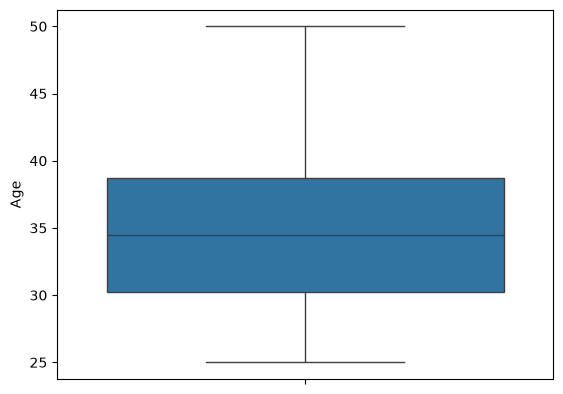

In [130]:
import seaborn as sns

sns.boxplot(data=df["Age"])

# Part 3 — Encoding Categorical Variables

### Q17. Label-encode `Education` (ordinal)
`Education` has a natural order: High School < Bachelor < Master < PhD. Create a new column `Education_Label` mapping these to 0, 1, 2, 3.

In [131]:
df['Education_Label'] = df['Education'].map(
{'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})

### Q18. Encode `Gender` as 0/1
`Gender` has only two values, so map Male -> 0 and Female -> 1 into a new column `Gender_Label`.

In [132]:
df['Gender_Label'] = df['Gender'].map({'Male':0, 'Female': 1})

### Q19. One-hot encode `Department` and `City`
These are **nominal** (no order), so use one-hot encoding. Use `pd.get_dummies` with prefixes `Dept` and `City`.

In [133]:
df = pd.get_dummies(df, columns=['Department', 'City'],
prefix=['Dept', 'City'])

### Q20. Inspect the final dataset
Print the final shape and the list of columns. Confirm there are no missing values.

In [134]:
print(df.shape)
print(df.isnull().sum())

(18, 16)
EmployeeID         0
Age                0
Gender             0
Education          0
Experience         0
Salary             0
Education_Label    0
Gender_Label       0
Dept_Finance       0
Dept_HR            0
Dept_IT            0
Dept_Sales         0
City_Bangalore     0
City_Delhi         0
City_Mumbai        0
City_Pune          0
dtype: int64


# Bonus Challenge

### Q21. Write a single `preprocess(df)` function
Combine everything into one reusable function that takes a raw DataFrame and returns the cleaned, encoded version. Test it by re-creating the raw data and passing it in.

In [136]:
from sklearn.impute import SimpleImputer
def cleaner(df):
    print("Shape:", df.shape)
    print("null_values",df.isnull().sum())

    #handelling null values 
    num_values=df.select_dtype(include=["numbers"].columns)
    cat_values=df.select_dtype(include=["Object"].columns)

    num_imputer=SimpleImputer(stratergy="median")
    cat_imputer=SimpleImputer(strategy="mode")

    df[num_values]=num_imputer.fit_transform(df[num_values])
    df[cat_values]=cat_imputer.fit_transform(df[cat_values])

    #calculating the quartiles
    for col in df.columns:
        Q1, Q3 =df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3- Q1
        mask &=df[col].between(Q1- 1.5*IQR,Q3 + 1.5*IQR)
        df = df[mask].reset_index(drop=True)

    #removing the outliers 
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

    
    print(df)
    print(df.shape)